In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [10]:
import os
print(os.listdir('/content/'))

['.config', 'sample_data']


In [12]:
import os
files = os.listdir('/content/')
for f in files:
    print(f)

.config
sample_data


In [13]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [14]:
import os
print(os.listdir('/content/'))

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [15]:
# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges column (has spaces instead of nulls)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Convert Churn to binary
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Dataset Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nData Cleaned Successfully! ✅")

Dataset Shape: (7032, 22)

Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Data Cleaned Successfully! ✅


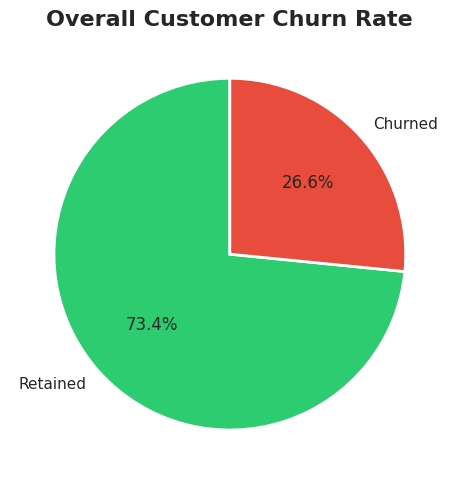

Insight: 26.5% of customers churned — roughly 1 in 4 customers!


In [16]:
# CHART 1 - Overall Churn Rate
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(7, 5))
plt.pie(churn_counts, labels=['Retained', 'Churned'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Overall Customer Churn Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_churn_rate.png', dpi=150)
plt.show()
print("Insight: 26.5% of customers churned — roughly 1 in 4 customers!")

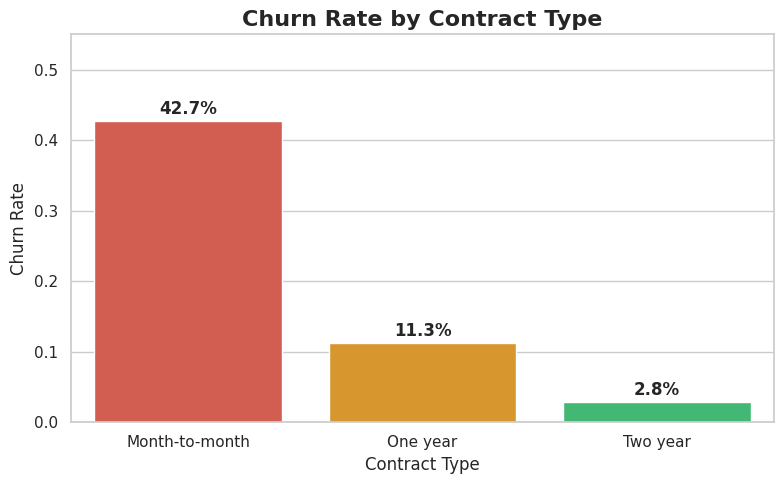

Insight: Month-to-month customers churn at 42% vs only 3% for 2-year contracts!


In [17]:
# CHART 2 - Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=contract_churn, x='Contract', y='Churn_Binary',
                 palette=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.55)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_contract_churn.png', dpi=150)
plt.show()
print("Insight: Month-to-month customers churn at 42% vs only 3% for 2-year contracts!")

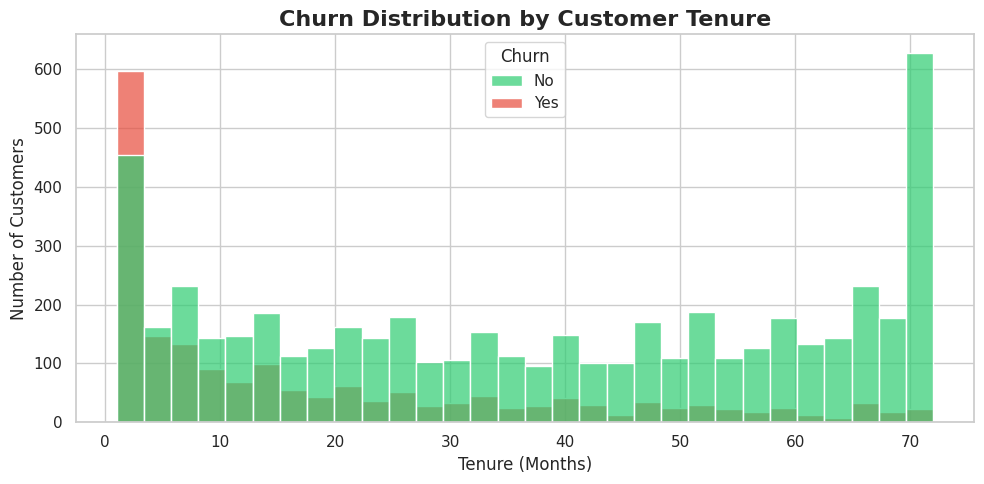

Insight: New customers (0-12 months) are at highest churn risk!


In [18]:
# CHART 3 - Churn by Tenure
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, alpha=0.7)
plt.title('Churn Distribution by Customer Tenure', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart3_tenure_churn.png', dpi=150)
plt.show()
print("Insight: New customers (0-12 months) are at highest churn risk!")

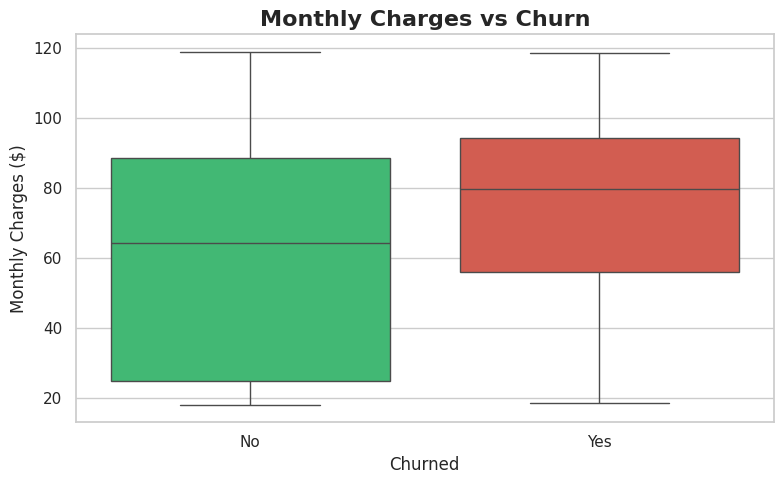

Insight: Churned customers paid higher monthly charges (~$74 vs $61)!


In [19]:
# CHART 4 - Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
plt.title('Monthly Charges vs Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churned')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('chart4_charges_churn.png', dpi=150)
plt.show()
print("Insight: Churned customers paid higher monthly charges (~$74 vs $61)!")

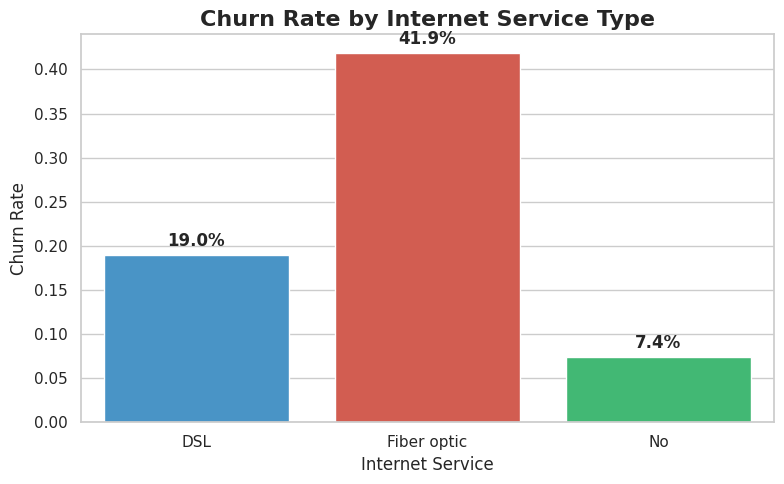

Insight: Fiber Optic customers churn at 42% — highest among all internet types!


In [20]:
# CHART 5 - Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=internet_churn, x='InternetService', y='Churn_Binary',
                 palette=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Churn Rate by Internet Service Type', fontsize=16, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01,
            f'{p.get_height():.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_internet_churn.png', dpi=150)
plt.show()
print("Insight: Fiber Optic customers churn at 42% — highest among all internet types!")

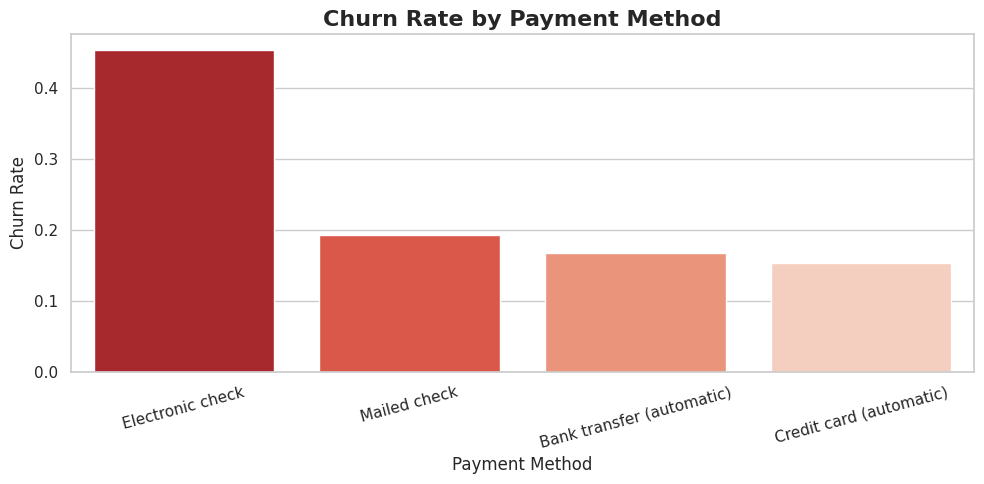

Insight: Electronic check users churn the most (45%)!


In [21]:
# CHART 6 - Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean().reset_index()
payment_churn = payment_churn.sort_values('Churn_Binary', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Binary', palette='Reds_r')
plt.title('Churn Rate by Payment Method', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart6_payment_churn.png', dpi=150)
plt.show()
print("Insight: Electronic check users churn the most (45%)!")

In [23]:
print("=" * 54)
print("     CUSTOMER CHURN ANALYSIS - KEY INSIGHTS")
print("=" * 54)
print("1. Overall churn rate is 26.5% — 1 in 4 customers")
print("2. Month-to-month contracts churn at 42%")
print("3. New customers (0-12 months) are highest risk")
print("4. Churned customers pay ~$13 more per month")
print("5. Fiber Optic users churn at 42%")
print("6. Electronic check payment = highest churn (45%)")
print("=" * 54)
print("")
print("BUSINESS RECOMMENDATIONS:")
print("-> Offer discounts to convert to annual contracts")
print("-> Create loyalty program for first 12 months")
print("-> Investigate Fiber Optic service quality")
print("-> Promote auto-pay over electronic checks")

     CUSTOMER CHURN ANALYSIS - KEY INSIGHTS
1. Overall churn rate is 26.5% — 1 in 4 customers
2. Month-to-month contracts churn at 42%
3. New customers (0-12 months) are highest risk
4. Churned customers pay ~$13 more per month
5. Fiber Optic users churn at 42%
6. Electronic check payment = highest churn (45%)

BUSINESS RECOMMENDATIONS:
-> Offer discounts to convert to annual contracts
-> Create loyalty program for first 12 months
-> Investigate Fiber Optic service quality
-> Promote auto-pay over electronic checks
